# Laboratorio 4 — Inciso 5: Análisis espacial

Se visualiza la distribución espacial del índice de cianobacteria dentro de cada lago con un mapa interactivo (folium) y se comparan mapas entre distintas fechas usando la misma escala de color, para poder interpretar dónde se concentran los valores altos y si hay zonas de acumulación persistente.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import folium
from folium.raster_layers import ImageOverlay

from src.config import FECHAS_OFICIALES, LAGOS, RUTA_DATA_PROCESSED, RUTA_FIGURAS
from src.descarga import ruta_raster
from src.raster import abrir, recorte_percentil

serie_temporal = pd.read_csv(RUTA_DATA_PROCESSED / "serie_temporal_cianobacteria.csv", parse_dates=["fecha"])


## 5.1 Mapa interactivo de distribución de cianobacteria (folium)

Para la fecha más reciente de cada lago, el raster de `clorofila` se convierte en una imagen a color (colormap `viridis`, recortado al percentil 2–98 como en el inciso 3) con transparencia fuera del agua, y se superpone sobre un mapa base real usando las coordenadas del bounding box del lago.


In [2]:
def raster_a_imagen_rgba(banda, agua, vmin, vmax, cmap_nombre="viridis"):
    cmap = matplotlib.colormaps[cmap_nombre]
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    rgba = cmap(norm(banda))
    rgba[..., 3] = np.where(agua > 0, 0.85, 0.0)
    return (rgba * 255).astype(np.uint8)


In [3]:
def mapa_folium(lago, fecha, cmap_nombre="viridis"):
    bandas = abrir(ruta_raster(lago, fecha))
    agua = bandas["agua"] > 0
    _, vmin, vmax = recorte_percentil(bandas["clorofila"], bandas["agua"])
    imagen = raster_a_imagen_rgba(bandas["clorofila"], agua, vmin, vmax, cmap_nombre)

    west, south, east, north = LAGOS[lago]["bbox"]
    mapa = folium.Map(tiles="CartoDB positron")
    mapa.fit_bounds([[south, west], [north, east]])
    ImageOverlay(
        image=imagen,
        bounds=[[south, west], [north, east]],
        opacity=0.85,
        name=f"Cianobacteria {fecha}",
    ).add_to(mapa)
    folium.LayerControl().add_to(mapa)
    return mapa



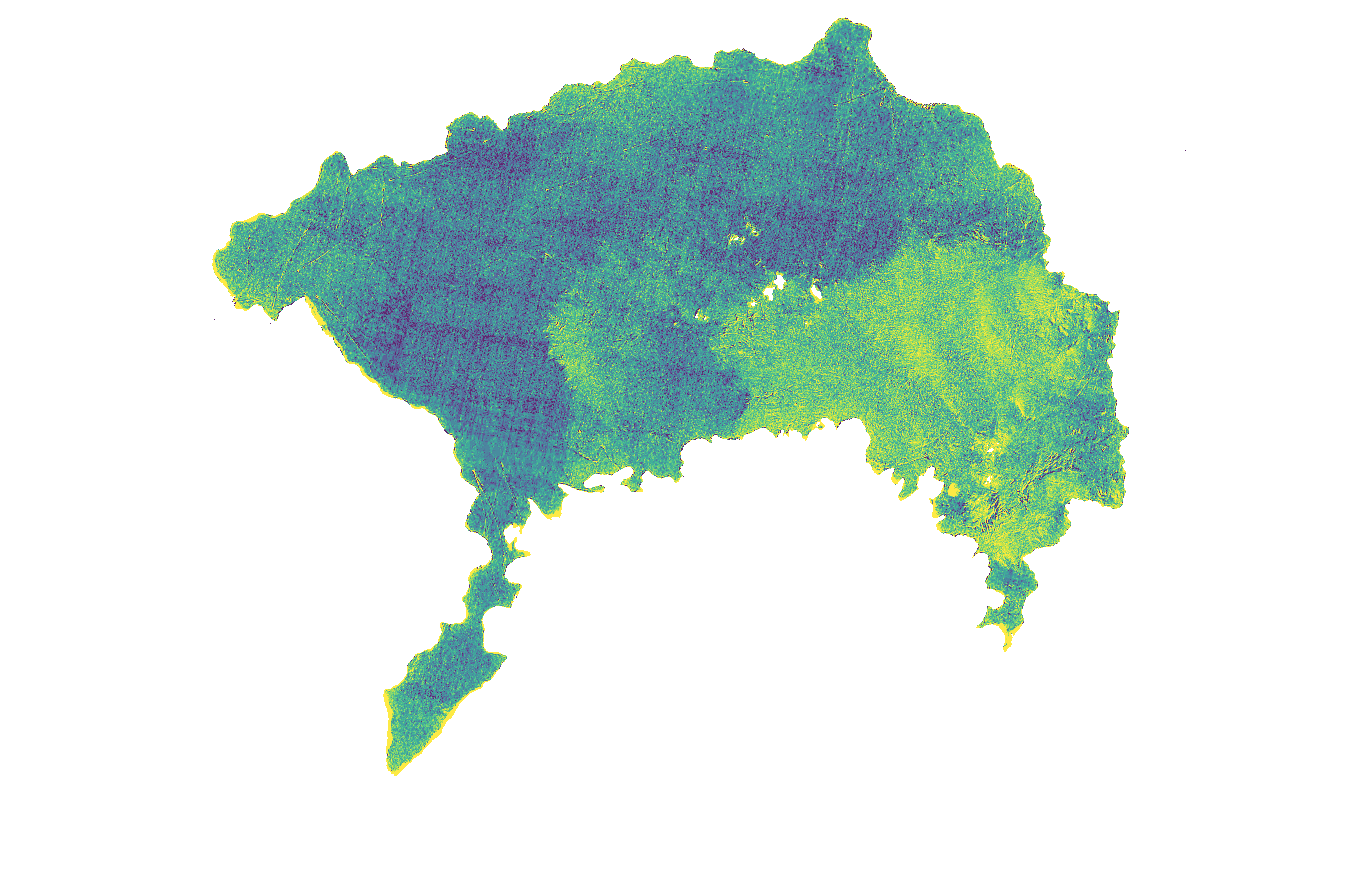

In [4]:
fecha_atitlan = FECHAS_OFICIALES["atitlan"][-1]
mapa_atitlan = mapa_folium("atitlan", fecha_atitlan)
mapa_atitlan.save(str(RUTA_FIGURAS / f"mapa_atitlan_{fecha_atitlan}.html"))
mapa_atitlan



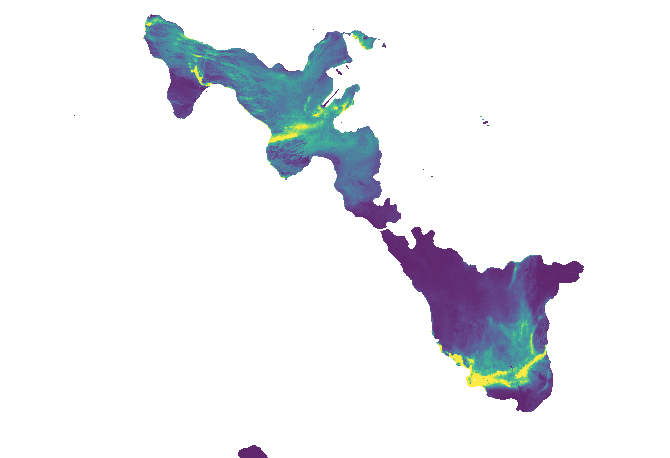

In [5]:
fecha_amatitlan = FECHAS_OFICIALES["amatitlan"][-1]
mapa_amatitlan = mapa_folium("amatitlan", fecha_amatitlan)
mapa_amatitlan.save(str(RUTA_FIGURAS / f"mapa_amatitlan_{fecha_amatitlan}.html"))
mapa_amatitlan


## 5.2 Mapas comparativos entre fechas

Para comparar distintas fechas de forma justa, todos los mapas de un mismo lago deben usar **la misma escala de color** (a diferencia del inciso 3, donde cada mapa se recortaba a su propio percentil). Se seleccionan tres fechas representativas por lago: la primera, la fecha con el valor promedio más alto (según el inciso 4), y la más reciente.


In [6]:
def rango_global(lago, percentiles=(2, 98)):
    todos = []
    for fecha in FECHAS_OFICIALES[lago]:
        bandas = abrir(ruta_raster(lago, fecha))
        agua = bandas["agua"] > 0
        todos.append(bandas["clorofila"][agua])
    todos = np.concatenate(todos)
    return tuple(np.percentile(todos, percentiles))

rangos = {lago: rango_global(lago) for lago in LAGOS}
rangos


{'atitlan': (np.float64(-1.5017707347869873), np.float64(3.497959613800049)),
 'amatitlan': (np.float64(3.1571614742279053), np.float64(21.414703369140625))}

In [7]:
fechas_comparativas = {}
for lago in LAGOS:
    fechas = FECHAS_OFICIALES[lago]
    fecha_pico = (
        serie_temporal[serie_temporal["lago"] == lago]
        .sort_values("clorofila_promedio", ascending=False)
        .iloc[0]["fecha"].strftime("%Y-%m-%d")
    )
    fechas_comparativas[lago] = sorted(set([fechas[0], fecha_pico, fechas[-1]]))

fechas_comparativas


{'atitlan': ['2025-01-18', '2026-04-13', '2026-07-22'],
 'amatitlan': ['2025-01-28', '2026-06-19']}

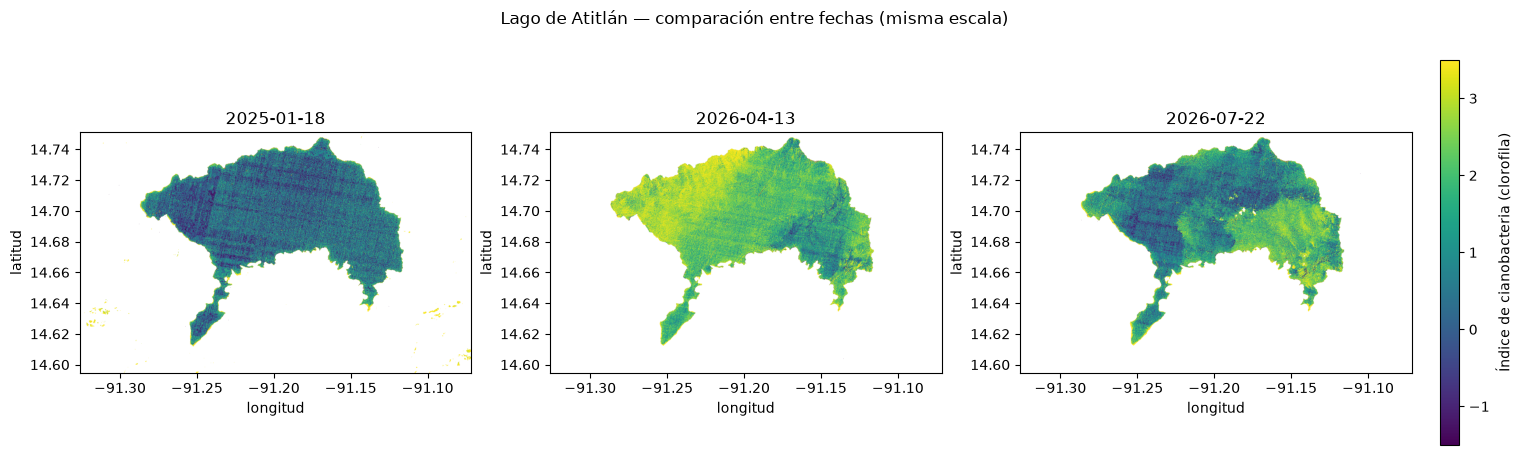

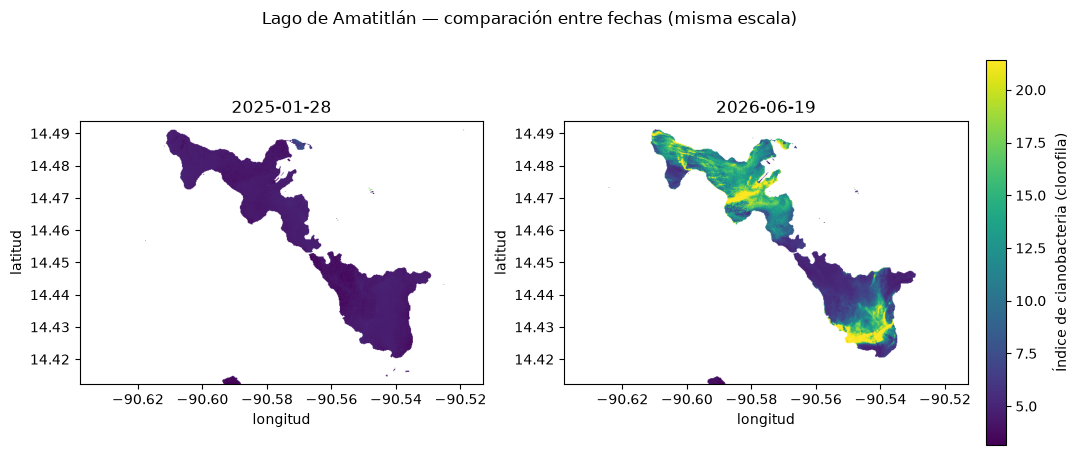

In [8]:
for lago in LAGOS:
    fechas_sel = fechas_comparativas[lago]
    vmin, vmax = rangos[lago]
    west, south, east, north = LAGOS[lago]["bbox"]

    fig, axes = plt.subplots(1, len(fechas_sel), figsize=(6 * len(fechas_sel), 5))
    for ax, fecha in zip(axes, fechas_sel):
        bandas = abrir(ruta_raster(lago, fecha))
        agua = bandas["agua"] > 0
        capa = np.where(agua, bandas["clorofila"], np.nan)
        im = ax.imshow(capa, cmap="viridis", vmin=vmin, vmax=vmax, extent=(west, east, south, north))
        ax.set_title(fecha)
        ax.set_xlabel("longitud")
        ax.set_ylabel("latitud")

    fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="Índice de cianobacteria (clorofila)")
    fig.suptitle(f"{LAGOS[lago]['nombre']} — comparación entre fechas (misma escala)")
    fig.savefig(RUTA_FIGURAS / f"comparacion_fechas_{lago}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 5.3 Interpretación

**Atitlán:** la zona de valores altos **no es fija**, se mueve entre fechas. En 2026-04-13 se concentra en la franja norte y el cuerpo central; en 2026-07-22 el máximo se desplaza al brazo este. No hay una zona de acumulación persistente clara, lo que sugiere que depende de condiciones puntuales (viento, corrientes superficiales) más que de una fuente fija de contaminación. Los puntos amarillos aislados junto a la costa suroeste en 2025-01-18 son píxeles mixtos de borde (denominador del NDCI cercano a cero, ya señalado en el inciso 3) y no floraciones reales.

**Amatitlán:** en 2025-01-28 el índice es bajo y casi uniforme en todo el lago (4–5). En 2026-06-19 aparecen dos zonas **persistentes y muy marcadas** de valores extremos (>18–20): el istmo que conecta el brazo norte con el cuerpo principal, y la bahía sur. Ambas son zonas someras y de circulación reducida, condición que favorece la acumulación de biomasa algal. El cuerpo central/abierto sube también, pero de forma más moderada (10–15).

**En conjunto:** Amatitlán no solo tiene valores promedio más altos (inciso 4); su floración es además más heterogénea espacialmente, con hotspots definidos en zonas de baja circulación. Atitlán sube de forma más pareja, sin una zona de acumulación fija en el período estudiado.
